# Connect 4 Win Detection
Detects whether either player has won a game of connect 4

# Details
Connect 4 is a game played on a 6 x 7 board where players take turns placing pieces, aiming to have 4 of their pieces arranged vertically, horizontally, or diagonally before their opponent. 
Detecting which player has won has multiple challenges:
1. Detecting the different arrangements winning pieces can be in
2. Determining which player has won from the arrangement of pieces
3. Determining if neither player has won

# Load Project Dependencies
Note: make sure you use python version 3.13

In [22]:
%pip install --upgrade pip
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Dataset
The dataset for this project is from UCI.edu, and can be found [here](https://archive.ics.uci.edu/dataset/26/connect+4)
The exact .csv raw data can be found [here](https://archive.ics.uci.edu/static/public/26/data.csv)

# Exploratory Data Analysis
* Uneven ratio between the three possible results
* Visualize frequency of different board positions being occupied
    * We can see positions near the top of the board are occupied less frequently, which makes sense given the rules of Connect 4


Shape: (67557, 43)


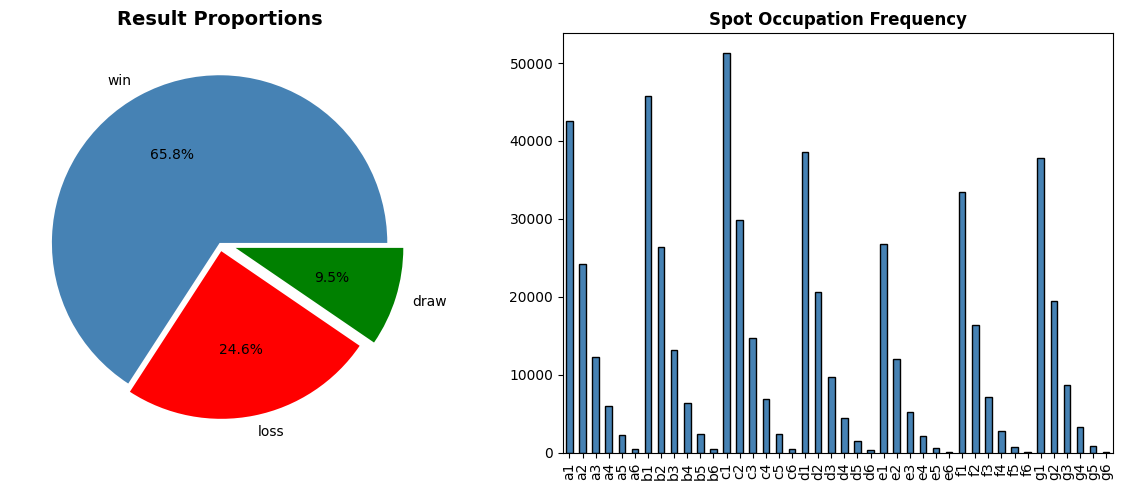

In [24]:
# read raw data
file = "./../data/raw/data.csv"

df = pd.read_csv(file)

print(f"Shape: {df.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'red', 'green']

df['class'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=colors, explode=[0, 0.05, 0.1])
axes[0].set_title("Result Proportions", fontsize=14, fontweight='bold')
axes[0].set_ylabel("")

dup = df.copy()

(dup.drop(columns="class") != 'b').sum().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title("Spot Occupation Frequency", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Data Processing
* We need to convert the dataset from strings to numbers
* We do not need to scale the values, as they are always one of 3 discrete values

In [25]:
def string_to_numerical_value(val):
    # columns/rows
    if val == "b":
        return 0
    if val == "x":
        return 1
    if val == "o":
        return -1
    
    # win state (between 0 and 1 for sigmoid)
    if val == "win":
        return 1
    if val == "loss":
        return 0
    if val == "draw":
        return 0.5
    
    raise ValueError(f"Unknown value: {val}")

# process raw data into processed data

processed = df.copy()

# convert to numerical values
for col in processed.columns:
    processed[col] = processed[col].apply(string_to_numerical_value)

# write to processed
split = file.split('/') if '/' in file else file.split('\\')
out_file = '/'.join(split[:-1]) + "/../processed/data.csv"
print(f"output saved to {out_file}")
processed.to_csv(out_file, index=False)

output saved to ./../data/raw/../processed/data.csv


# Data Split
We want a relatively even split of wins and losses. Otherwise, the model will be >60% accurate by just selecting "win" every time.
To do this we take a random sample of wins and losses in an equal amount to the number of ties to create a new data set with an even number of each

output saved to ./../data/raw/../processed/evened.csv


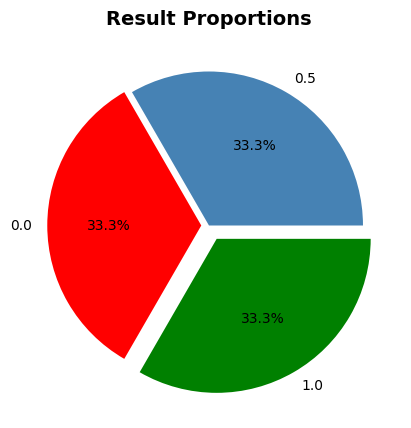

In [26]:
wins = processed[processed["class"] == 1]
losses = processed[processed["class"] == 0]
evened = processed[processed["class"] == 0.5]

# since ties make up the smallest portion, we'll keep all of them and re-add an equal number of wins and losses
portion_size = len(evened)
evened = pd.concat([evened, wins.sample(n=portion_size)], ignore_index=True)
evened = pd.concat([evened, losses.sample(n=portion_size)], ignore_index=True)

# shuffle rows
evened = evened.sample(frac=1)

fig, axes = plt.subplots(1, 1, figsize=(12, 5))
colors = ['steelblue', 'red', 'green']

evened['class'].value_counts().plot(kind='pie', ax=axes, autopct='%1.1f%%', colors=colors, explode=[0, 0.05, 0.1])
axes.set_title("Result Proportions", fontsize=14, fontweight='bold')
axes.set_ylabel("")


# write to processed
split = file.split('/') if '/' in file else file.split('\\')
out_file = '/'.join(split[:-1]) + "/../processed/evened.csv"
print(f"output saved to {out_file}")
evened.to_csv(out_file, index=False)

In [45]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("./../data/processed/evened.csv")

y = df['class']
x = df.drop(columns=['class'])
train_X, test_X, train_Y, test_Y = train_test_split(x, y, test_size=0.2)

# reshape into the shape of the 6 x 7 board so we can look for neighboring pieces
train_X = train_X.values.reshape(-1, 6, 7, 1)
test_X = test_X.values.reshape(-1, 6, 7, 1)

# Create Model
A convolutional neural network is a good choice for this problem because the answer depends on clusters of inputs close to each other.
For the model to work properly, the inputs need to be arranged in the shape of the board so the convolutional layers can process them effectively.

In [114]:
from tensorflow.keras import layers, models, Input

# a simple CNN implementation with a single convolutional layer and a 
model = models.Sequential([
    Input(shape=(6, 7, 1)),
    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),

    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Output between 0 and 1
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    train_X, train_Y, 
    epochs=15, 
    batch_size=32, 
    validation_data=(test_X, test_Y)
)

result = model.evaluate(test_X, test_Y, batch_size=32)

print(f"Test Loss: {result}")

Epoch 1/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1111 - val_loss: 0.0981
Epoch 2/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0972 - val_loss: 0.0900
Epoch 3/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0891 - val_loss: 0.0836
Epoch 4/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0833 - val_loss: 0.0811
Epoch 5/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0787 - val_loss: 0.0775
Epoch 6/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0750 - val_loss: 0.0752
Epoch 7/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0720 - val_loss: 0.0738
Epoch 8/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0695 - val_loss: 0.0733
Epoch 9/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0670 - val_loss: 0.0722
Epoch 10/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0648 - val_loss: 0.0720
Epoch 11/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0629 - val_loss: 0.0714
Epoch 12/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

# Model Improvements (based on reasearch and experimentation)
* An additional, smaller convolutional layer reduces the number of inputs being directly fed to the dense layer
* A Dropout helps to reduce overfitting, which is otherwise significantly higher on this model due to the extra layer
The improvement is small (test loss decreasing from 0.068 to ~0.064), but consistent

In [119]:
from tensorflow.keras import layers, models

model = models.Sequential([
    Input(shape=(6, 7, 1)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(16, (1, 1), activation='relu'),
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1), # reduce overfitting
    
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='mse')

history2 = model.fit(
    train_X, train_Y, 
    epochs=15, 
    batch_size=32, 
    validation_data=(test_X, test_Y)
)


result = model.evaluate(test_X, test_Y, batch_size=32)

print(f"Test Loss: {result}")

Epoch 1/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1093 - val_loss: 0.0932
Epoch 2/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0916 - val_loss: 0.0889
Epoch 3/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0830 - val_loss: 0.0793
Epoch 4/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0770 - val_loss: 0.0783
Epoch 5/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0723 - val_loss: 0.0735
Epoch 6/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0689 - val_loss: 0.0711
Epoch 7/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0660 - val_loss: 0.0723
Epoch 8/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0633 - val_loss: 0.0688
Epoch 9/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0612 - val_loss: 0.0676
Epoch 10/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0589 - val_loss: 0.0662
Epoch 11/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0570 - val_loss: 0.0679
Epoch 12/15
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

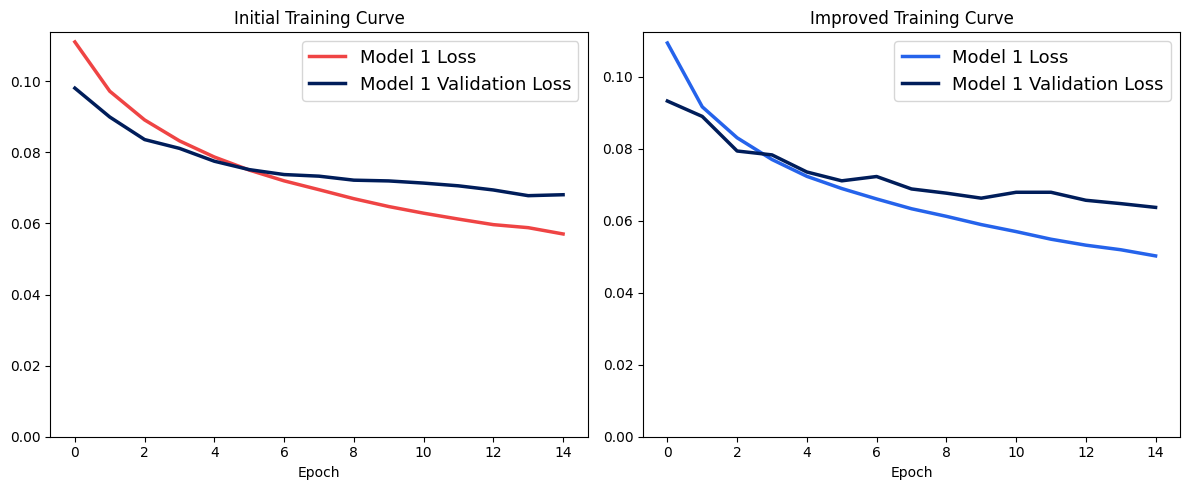

In [120]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].plot(history.history["loss"],  color='#EF4444', 
        linewidth=2.5, label='Model 1 Loss')


ax[0].plot(history.history["val_loss"],  color="#001D5A", 
        linewidth=2.5, label='Model 1 Validation Loss')


ax[1].plot(history2.history["loss"],  color="#2563EB", 
        linewidth=2.5, label='Model 1 Loss')


ax[1].plot(history2.history["val_loss"],  color="#001D5A", 
        linewidth=2.5, label='Model 1 Validation Loss')


ax[0].set_xlabel('Epoch')
ax[0].set_title('Initial Training Curve')
ax[0].legend(fontsize=13)
ax[0].set_ylim(0, None)

ax[1].set_xlabel('Epoch')
ax[1].set_title('Improved Training Curve')
ax[1].legend(fontsize=13)
ax[1].set_ylim(0, None)


plt.tight_layout()
plt.show()